<a href="https://colab.research.google.com/github/ShivamVats1/-Customer-Loyalty-Prediction-in-E-Commerce/blob/main/impulse_buyer_refined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

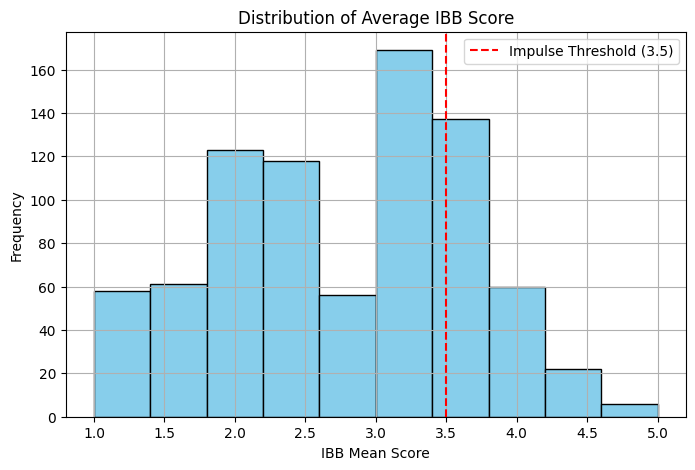

📌 Logistic Regression:
               precision    recall  f1-score   support

           0       0.69      0.69      0.69       117
           1       0.69      0.69      0.69       117

    accuracy                           0.69       234
   macro avg       0.69      0.69      0.69       234
weighted avg       0.69      0.69      0.69       234

📌 Random Forest:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       117
           1       0.92      0.92      0.92       117

    accuracy                           0.92       234
   macro avg       0.92      0.92      0.92       234
weighted avg       0.92      0.92      0.92       234

📌 XGBoost:
               precision    recall  f1-score   support

           0       0.91      0.81      0.86       117
           1       0.83      0.92      0.87       117

    accuracy                           0.87       234
   macro avg       0.87      0.87      0.87       234
weighted avg       0

In [ ]:


  # 📦 Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ⚙️ ML Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 🎯 Evaluation
from sklearn.metrics import classification_report, accuracy_score

# 📈 Preprocessing
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# 📢 SHAP
!pip install shap -q
import shap
import warnings
warnings.filterwarnings('ignore')


# 📂 Load Data
df = pd.read_csv('Raw Data_Paylater and Non Paylater User.csv', sep=';')
df.dropna(inplace=True)

# 🎯 Target Creation
df['IBB_score'] = df[['IBB1', 'IBB2', 'IBB3', 'IBB4']].mean(axis=1)
df['is_impulse'] = (df['IBB_score'] >= 3.5).astype(int)


############# Label Threshold Justification (Histogram Plot)###
plt.figure(figsize=(8, 5))
plt.hist(df['IBB_score'], bins=10, color='skyblue', edgecolor='black')
plt.axvline(3.5, color='red', linestyle='--', label='Impulse Threshold (3.5)')
plt.title("Distribution of Average IBB Score")
plt.xlabel("IBB Mean Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


# 🔤 Encode Categorical Columns
cat_cols = ['Gender', 'E-Paylater User Status', 'Educational Background', 'Job Status']
df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)

# ✅ Select Features
drop_cols = ['IBB1', 'IBB2', 'IBB3', 'IBB4', 'IBB_score']
X = df.drop(columns=drop_cols + ['is_impulse'])
y = df['is_impulse']

# ⚖️ Balance Classes with Random OverSampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 📊 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 🔍 Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
print("📌 Logistic Regression:\n", classification_report(y_test, lr.predict(X_test)))

# 🌲 Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("📌 Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

# 🚀 XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
print("📌 XGBoost:\n", classification_report(y_test, xgb.predict(X_test)))


# Save predictions for reuse
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)


# 🔍 Accuracy Comparison
print("\n✅ Model Accuracy Comparison:")
print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))
print("XGBoost:", accuracy_score(y_test, xgb.predict(X_test)))



## Newly added 10-Fold Cross-Validation for All ***Models***

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f" Cross-Validation Results: {name}")
    for score in scoring_metrics:
        cv_scores = cross_val_score(model, X_smote, y_smote, cv=skf, scoring=score)
        print(f"  {score}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print("-" * 50)


📊 Cross-Validation Results: Logistic Regression
  accuracy: 0.7282 ± 0.0348
  precision: 0.7247 ± 0.0407
  recall: 0.7401 ± 0.0483
  f1: 0.7312 ± 0.0341
  roc_auc: 0.8170 ± 0.0351
--------------------------------------------------
📊 Cross-Validation Results: Random Forest
  accuracy: 0.8376 ± 0.0359
  precision: 0.8412 ± 0.0340
  recall: 0.8323 ± 0.0529
  f1: 0.8361 ± 0.0389
  roc_auc: 0.9118 ± 0.0251
--------------------------------------------------
📊 Cross-Validation Results: XGBoost
  accuracy: 0.8162 ± 0.0396
  precision: 0.8080 ± 0.0382
  recall: 0.8307 ± 0.0636
  f1: 0.8180 ± 0.0419
  roc_auc: 0.8980 ± 0.0305
--------------------------------------------------


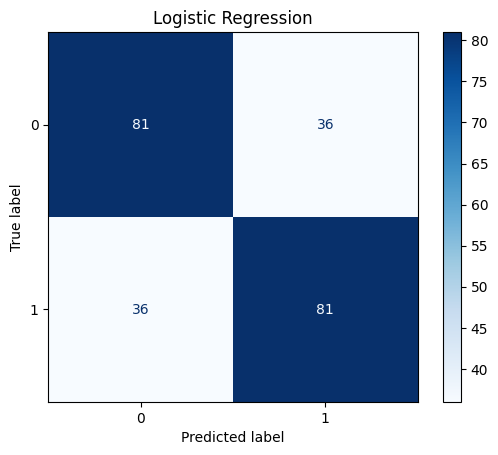

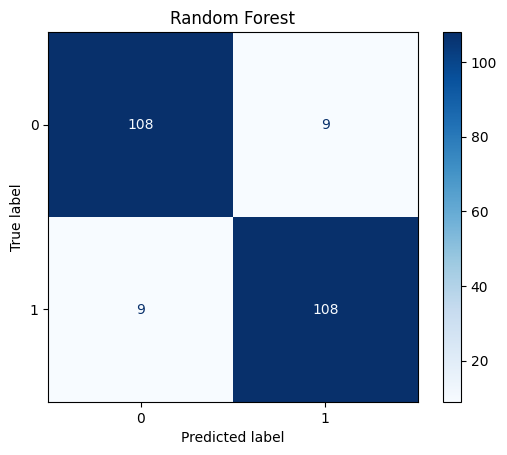

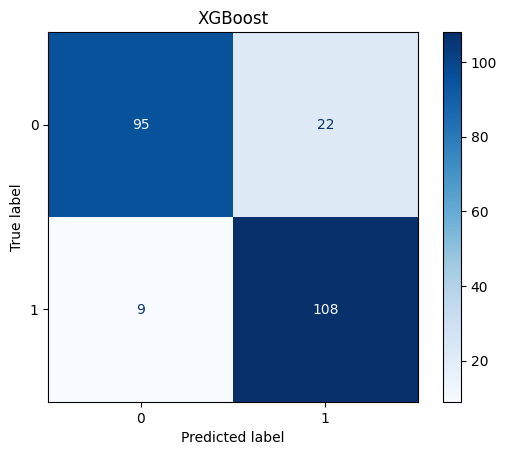

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

# Plot for each model
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost")


📌 Random Forest (SMOTE):
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       117
           1       0.80      0.77      0.79       117

    accuracy                           0.79       234
   macro avg       0.79      0.79      0.79       234
weighted avg       0.79      0.79      0.79       234



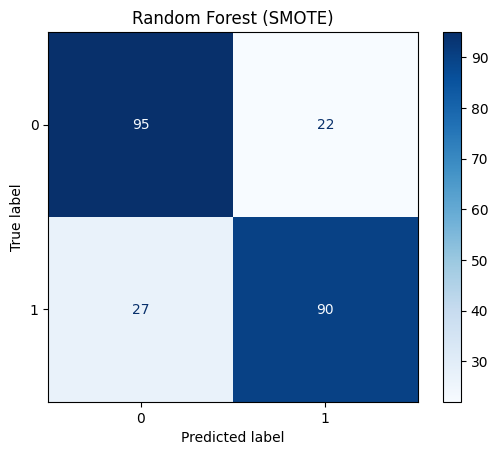

In [ ]:
from imblearn.over_sampling import SMOTE

# Use SMOTE instead of ROS
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)

# New train-test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# Train and predict with Random Forest (as example)
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_s, y_train_s)
y_pred_rf_smote = rf_smote.predict(X_test_s)

# Evaluation
print("📌 Random Forest (SMOTE):\n", classification_report(y_test_s, y_pred_rf_smote))
plot_conf_matrix(y_test_s, y_pred_rf_smote, "Random Forest (SMOTE)")


 94%|=================== | 439/468 [00:12<00:00]       

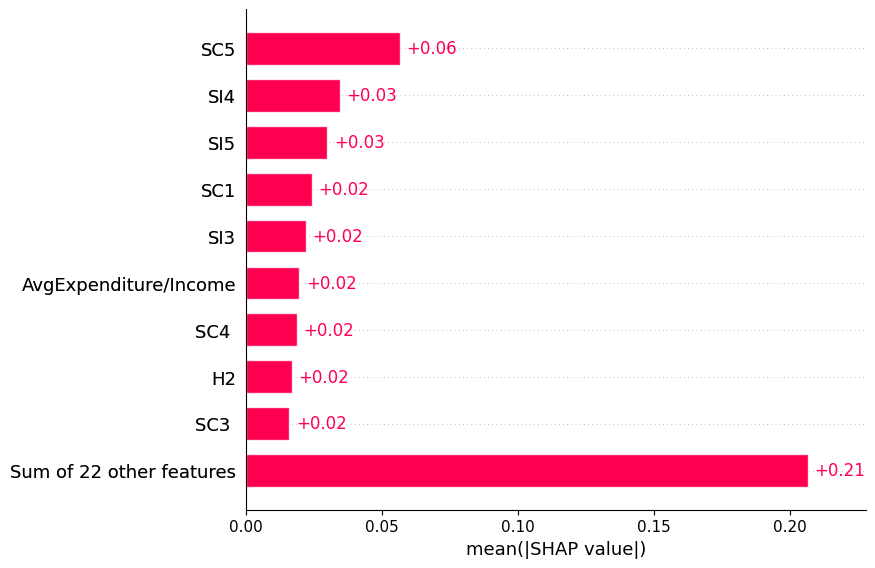

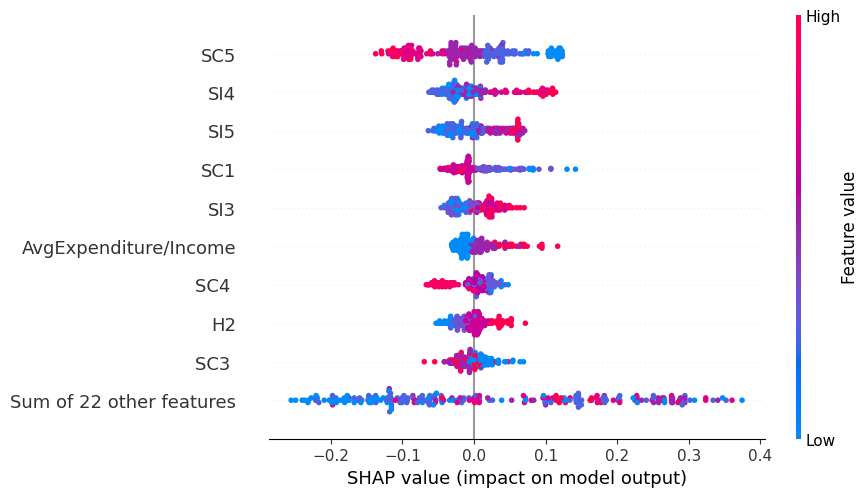

In [ ]:
 # ------------------- SHAP EXPLAINABILITY (FIXED + CLEANED LABELS) ----------------------

# Rename long feature names in a copy of the training/test data
X_test_short = X_test.copy()
X_train_short = X_train.copy()

X_test_short.rename(columns={
    "Average monthly expenditure for online shopping in relation to monthly income": "AvgExpenditure/Income"
}, inplace=True)

X_train_short.rename(columns={
    "Average monthly expenditure for online shopping in relation to monthly income": "AvgExpenditure/Income"
}, inplace=True)

# Re-train SHAP Explainer with consistent feature names
explainer = shap.Explainer(rf, X_train_short)

# Compute SHAP values for the test set
shap_values_full = explainer(X_test_short)  # shape: (n_samples, n_features, n_classes)

# Extract SHAP values for class 1 (impulse buyers)
shap_values_class1 = shap_values_full[..., 1]  # shape: (n_samples, n_features)

# Plot SHAP bar chart
shap.plots.bar(shap_values_class1)

# Plot SHAP beeswarm chart
shap.plots.beeswarm(shap_values_class1)

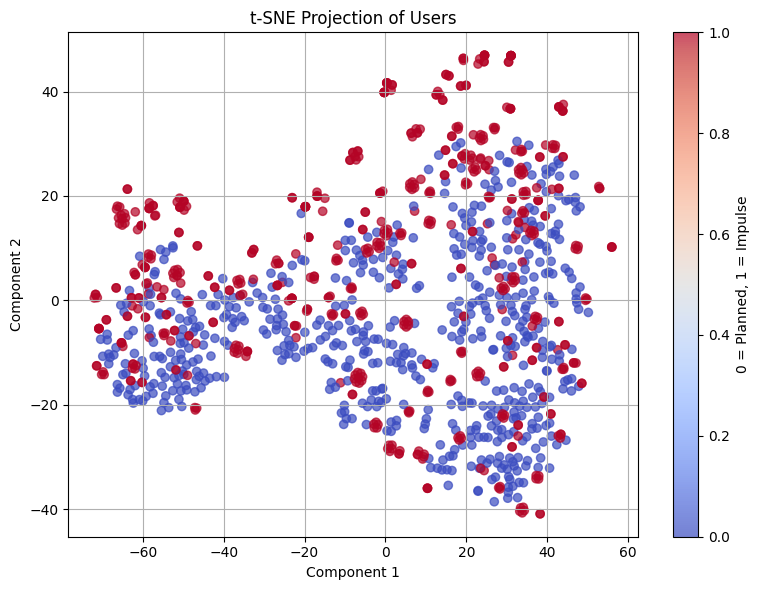

In [ ]:
# ------------------- 🧠 t-SNE PROJECTION FOR VISUAL INTUITION ----------------------

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_resampled)

# Plot t-SNE result
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1],
                      c=y_resampled, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE Projection of Users")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
cbar = plt.colorbar(scatter)
cbar.set_label("0 = Planned, 1 = Impulse")
plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Add Ablation Study (Remove One Feature Group at a Time)**bold text** italicized text

In [ ]:
feature_groups = {
    "All": X_smote.columns.tolist(),
    "No_SC": [f for f in X_smote.columns if not f.startswith("SC")],
    "No_SI": [f for f in X_smote.columns if not f.startswith("SI")],
    "No_H": [f for f in X_smote.columns if not f.startswith("H")],
    "No_IBB": [f for f in X_smote.columns if not f.startswith("IBB")]
}

print("🔬 Ablation Study on Feature Groups\n")
for group, cols in feature_groups.items():
    X_temp = X_smote[cols]
    X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(X_temp, y_smote, test_size=0.2, stratify=y_smote, random_state=42)
    rf_temp = RandomForestClassifier(random_state=42)
    rf_temp.fit(X_train_ab, y_train_ab)
    preds = rf_temp.predict(X_test_ab)
    acc = accuracy_score(y_test_ab, preds)
    print(f"{group} → Accuracy: {acc:.4f}")


🔬 Ablation Study on Feature Groups

All → Accuracy: 0.7906
No_SC → Accuracy: 0.7906
No_SI → Accuracy: 0.7863
No_H → Accuracy: 0.8034
No_IBB → Accuracy: 0.7906


# 4. t-SNE Visualization (Impulse vs Planned Buyers)**bold text** italicized text

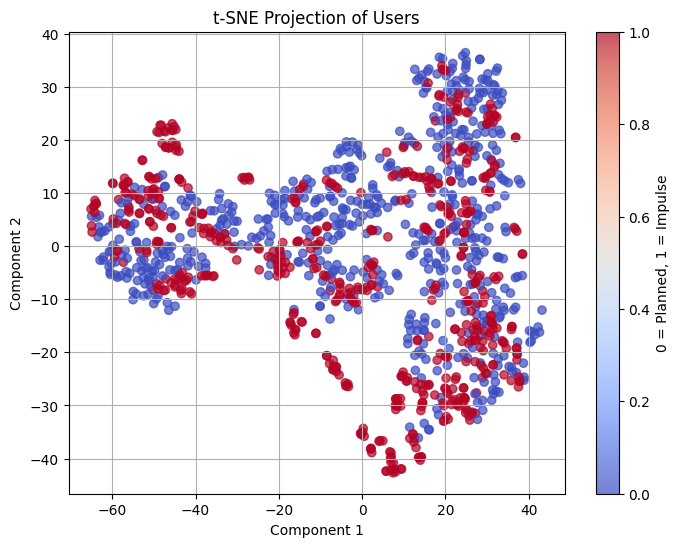

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X_smote)

plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_smote, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE Projection of Users")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='0 = Planned, 1 = Impulse')
plt.grid(True)
plt.show()


### ⚖️ Ethical Considerations

While predicting impulse buyers can enable personalized marketing and improve credit risk assessment, it also raises concerns. Such profiling could lead to over-targeting vulnerable users, exploit emotional triggers, or reinforce compulsive behavior. Therefore, we recommend using these models responsibly — with user consent, transparency, and ethical guardrails to ensure they benefit consumers rather than manipulate them.


END IS HERE

In [ ]:
print(df.columns.tolist())


['Gender', 'E-Paylater User Status', 'Educational Background', 'Year of Birth', 'Job Status', 'Monthly Income', 'Average monthly expenditure for online shopping in relation to monthly income', 'IBB1', 'IBB2', 'IBB3', 'IBB4', 'P1', 'P2', 'P3', 'P4', 'SI1', 'SI2', 'SI3', 'SI4', 'SI5', 'SI6', 'H1', 'H2', 'H3', 'H4', 'SC1', 'SC2', 'SC3 ', 'SC4 ', 'SC5', 'NE1', 'NE2', 'NE3', 'NE4', 'NE5', 'IBB_score', 'is_impulse']



# **Kmeans failed , not to be includedd text***




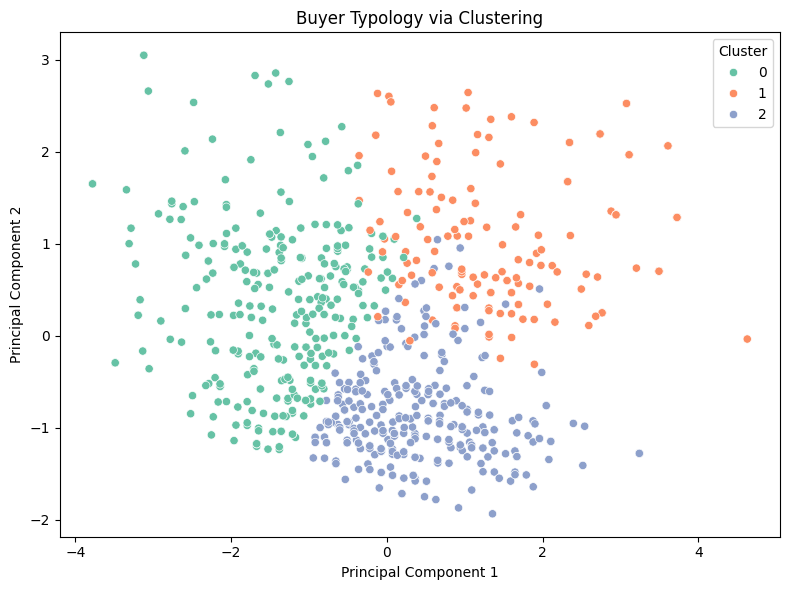

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select correct features
features = ['SC5', 'SI4', 'H2', 'IBB_score', 'E-Paylater User Status', 'Monthly Income']
X = df[features].copy()

# Optional: handle missing values if needed
X = X.dropna()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original df
df['Buyer_Type'] = clusters

# Plotting the clusters using the first two principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Buyer_Type', palette='Set2')
plt.title('Buyer Typology via Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('buyer_clusters.png', dpi=300)
plt.show()


In [ ]:
# Assuming your DataFrame is df and it already contains the cluster labels
# and the selected features were used in clustering

# Rename cluster column if not already done
df['Buyer_Type'] = kmeans.labels_ # Replace cluster_labels if it's named differently

# Define the corrected features
features = ['SC5', 'SI4', 'H2', 'IBB_score', 'E-Paylater User Status', 'Monthly Income']

# Get mean values per Buyer_Type
cluster_means = df.groupby('Buyer_Type')[features].mean()

# Display
print(cluster_means)


                 SC5       SI4        H2  IBB_score  E-Paylater User Status  \
Buyer_Type                                                                    
0           3.904605  1.634868  2.894737   2.053454                0.118421   
1           2.461538  3.254438  3.816568   3.284024                0.994083   
2           2.780415  2.489614  3.804154   3.125371                0.000000   

            Monthly Income  
Buyer_Type                  
0                 3.766447  
1                 3.195266  
2                 1.750742  


In [ ]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled,kmeans.labels_)
print(f"Silhouette Score: {sil_score:.2f}")


Silhouette Score: 0.22


In [ ]:
# Check unique income values
print(df['Monthly Income'].unique())


[3 2 1 6 4 5]


In [ ]:
income_map = {
    1: 'Below 1M IDR',
    2: '1M–2.5M IDR',
    3: '2.5M–5M IDR',
    4: '5M–7.5M IDR',
    5: '7.5M–10M IDR',
    6: 'Above 10M IDR'
}

df['income_label'] = df['Monthly Income'].map(income_map)


In [ ]:
df['income_group'] = df['Monthly Income'].apply(lambda x: 'Low Income' if x <= 3 else 'High Income')


In [ ]:
group_stats = df.groupby('income_group')['IBB_score'].mean()
print(group_stats)


income_group
High Income    2.671402
Low Income     2.797161
Name: IBB_score, dtype: float64


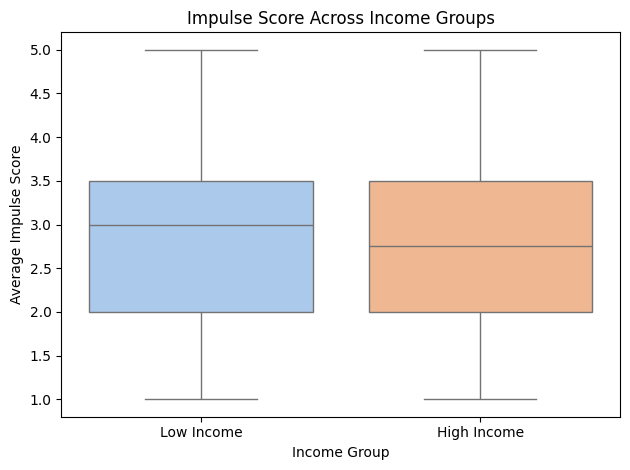

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='income_group', y='IBB_score', data=df, palette='pastel')
plt.title('Impulse Score Across Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Average Impulse Score')
plt.tight_layout()
plt.show()
